In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ai4i2020.csv")

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
df = df.drop(['UDI', 'Product ID'], axis=1)

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

In [6]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
df['Temp_Difference'] = (
    df['Process temperature [K]']
    - df['Air temperature [K]']
)

In [8]:
df[['Air temperature [K]',
    'Process temperature [K]',
    'Temp_Difference']].head()

,Air temperature [K],Process temperature [K],Temp_Difference
0,298.1,308.6,10.5
1,298.2,308.7,10.5
2,298.1,308.5,10.4
3,298.2,308.6,10.4
4,298.2,308.7,10.5


In [9]:
df['Power_Index'] = (
    df['Rotational speed [rpm]']
    * df['Torque [Nm]']
)

In [10]:
df[['Rotational speed [rpm]',
    'Torque [Nm]',
    'Power_Index']].head()

,Rotational speed [rpm],Torque [Nm],Power_Index
0,1551,42.8,66382.8
1,1408,46.3,65190.4
2,1498,49.4,74001.2
3,1433,39.5,56603.5
4,1408,40.0,56320.0


In [11]:
df['Wear_Torque'] = (
    df['Tool wear [min]']
    * df['Torque [Nm]']
)

In [12]:
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Temp_Difference',
       'Power_Index', 'Wear_Torque'],
      dtype='object')

In [13]:
X = df.drop('Machine failure', axis=1)

y = df['Machine failure']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
from sklearn.ensemble import RandomForestClassifier

model_v2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_v2.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [16]:
from sklearn.metrics import accuracy_score

pred_v2 = model_v2.predict(X_test)

accuracy_v2 = accuracy_score(y_test, pred_v2)

print("New Accuracy =", accuracy_v2)

New Accuracy = 0.999


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_v2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [18]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_v2.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                    Feature  Importance
7                       HDF    0.251485
9                       OSF    0.174032
8                       PWF    0.125182
6                       TWF    0.101246
12              Power_Index    0.096066
13              Wear_Torque    0.069926
4               Torque [Nm]    0.052908
3    Rotational speed [rpm]    0.047023
11          Temp_Difference    0.038429
5           Tool wear [min]    0.021558
1       Air temperature [K]    0.010537
2   Process temperature [K]    0.007547
0                      Type    0.003817
10                      RNF    0.000243


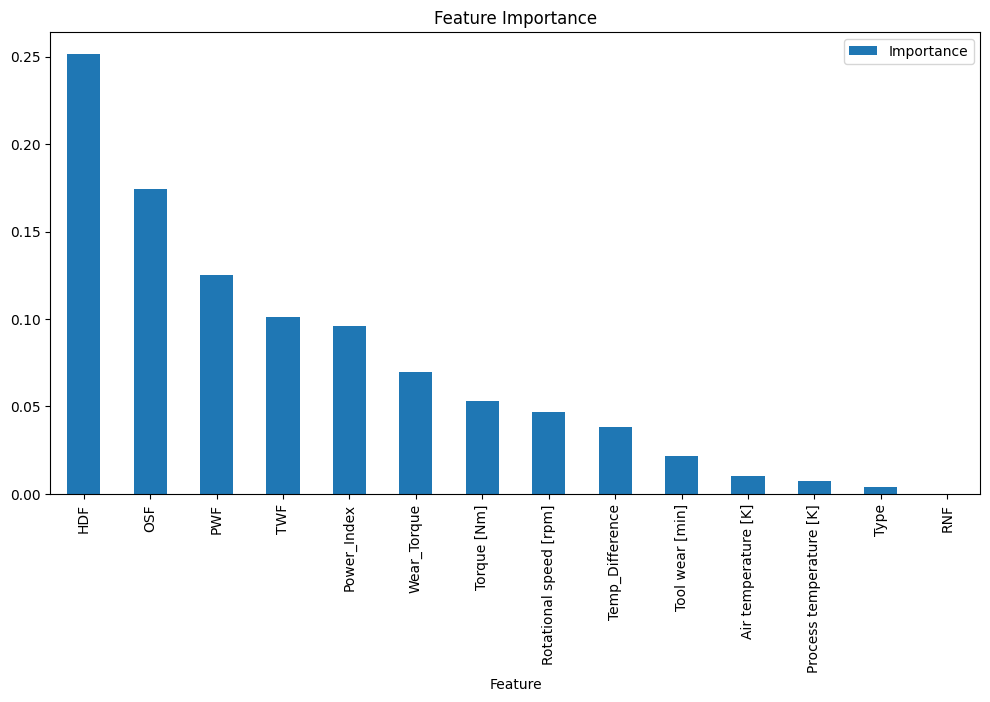

In [19]:
importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(12,6)
)

plt.title("Feature Importance")
plt.show()

In [20]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_v2.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                    Feature  Importance
7                       HDF    0.251485
9                       OSF    0.174032
8                       PWF    0.125182
6                       TWF    0.101246
12              Power_Index    0.096066
13              Wear_Torque    0.069926
4               Torque [Nm]    0.052908
3    Rotational speed [rpm]    0.047023
11          Temp_Difference    0.038429
5           Tool wear [min]    0.021558
1       Air temperature [K]    0.010537
2   Process temperature [K]    0.007547
0                      Type    0.003817
10                      RNF    0.000243
